In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Path to dataset files: /home/admin123/.cache/kagglehub/datasets/uciml/iris/versions/2


In [2]:
!ls $path

database.sqlite  Iris.csv


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(path+"/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print(df.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [5]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

In [6]:
X.head(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

In [9]:
def distance_func(p, q):
  return np.sqrt(np.sum((q-p)**2))

In [10]:
def find_nearests(X, y, point, K):
  distances = []
  for i in range(len(X)):
    train_point = X.iloc[i]
    train_eq = y.iloc[i]
    distance = distance_func(point, train_point)
    distances.append((distance, train_point[0], train_point[1], train_eq))
  distances.sort(key=lambda x: x[0])
  return distances[:K]


In [11]:
from collections import Counter

def KNN(X_train, y_train, test, K=3):
  return Counter([types[3] for types in find_nearests(X_train, y_train, test, K)]).most_common(1)[0][0]


In [12]:
correct_prediction = 0
total_length = len(X_test)
wrong_results = []
for i in range(total_length):
  test_point = X_test.iloc[i].values
  real = y_test.iloc[i]

  prediction = KNN(X_train, y_train, test_point, K=3)
  print(prediction, real)
  if prediction == real:
    correct_prediction+=1
  else:
    wrong_results.append((prediction, real, i))

accuracy = (correct_prediction/total_length)*100
print(accuracy,"%")

/tmp/ipykernel_468839/507164459.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  distances.append((distance, train_point[0], train_point[1], train_eq))


Iris-setosa Iris-setosa
Iris-setosa Iris-setosa
Iris-setosa Iris-setosa
Iris-versicolor Iris-versicolor
Iris-virginica Iris-virginica
Iris-versicolor Iris-versicolor
Iris-setosa Iris-setosa
Iris-versicolor Iris-versicolor
Iris-setosa Iris-setosa
Iris-versicolor Iris-versicolor
Iris-versicolor Iris-virginica
Iris-setosa Iris-setosa
Iris-virginica Iris-virginica
Iris-virginica Iris-virginica
Iris-setosa Iris-setosa
Iris-versicolor Iris-versicolor
Iris-setosa Iris-setosa
Iris-virginica Iris-virginica
Iris-virginica Iris-virginica
Iris-versicolor Iris-versicolor
Iris-setosa Iris-setosa
Iris-setosa Iris-setosa
Iris-setosa Iris-setosa
Iris-versicolor Iris-versicolor
Iris-setosa Iris-setosa
Iris-virginica Iris-virginica
Iris-setosa Iris-setosa
Iris-versicolor Iris-versicolor
Iris-versicolor Iris-versicolor
Iris-setosa Iris-setosa
96.66666666666667 %


In [13]:
wrong_results

[('Iris-versicolor', 'Iris-virginica', 10)]

/home/admin123/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/tmp/ipykernel_468839/507164459.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  distances.append((distance, train_point[0], train_point[1], train_eq))


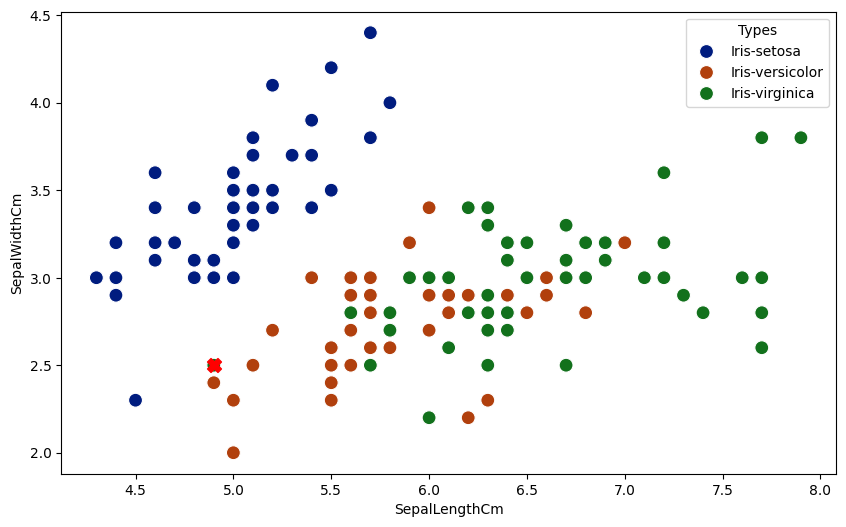

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
target_point = X_test.iloc[10].values
target_x = target_point[0]
target_y = target_point[1]
neighbors = find_nearests(X_train, y_train, target_point, K=3)

sns.scatterplot(x=df['SepalLengthCm'], y=df['SepalWidthCm'], hue=df['Species'], palette='dark', s=100)
plt.scatter(X_test.iloc[10, 0], X_test.iloc[10, 1], color='red', marker='X', s=100)

plt.legend(title='Types')
plt.show()